# Enhanced Student Performance Prediction Model
### Multi-Model Ensemble with Advanced Feature Engineering

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

In [12]:
# Load dataset
df = pd.read_csv('Student_Performance.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 6)


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [13]:
# Encode categorical variable
df['Extracurricular Activities'] = (df['Extracurricular Activities'] == 'Yes').astype(int)

# Feature Engineering - Add new calculated features
df['Study_Sleep_Ratio'] = df['Hours Studied'] / (df['Sleep Hours'] + 1)
df['Total_Effort'] = df['Hours Studied'] + df['Sample Question Papers Practiced']
df['Previous_Score_Normalized'] = df['Previous Scores'] / 100
df['Sleep_Efficiency'] = df['Sleep Hours'] * df['Previous Scores'] / 100

print("\nNew features added:")
print(df[['Study_Sleep_Ratio', 'Total_Effort', 'Previous_Score_Normalized', 'Sleep_Efficiency']].head())


New features added:
   Study_Sleep_Ratio  Total_Effort  Previous_Score_Normalized  \
0           0.700000             8                       0.99   
1           0.800000             6                       0.82   
2           1.000000            10                       0.51   
3           0.833333             7                       0.52   
4           0.777778            12                       0.75   

   Sleep_Efficiency  
0              8.91  
1              3.28  
2              3.57  
3              2.60  
4              6.00  


In [14]:
# Prepare features and target
X = df.drop('Performance Index', axis=1)
y = df['Performance Index']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (7500, 9)
Test set: (2500, 9)


In [15]:
# Train Multiple Models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    print(f"{'='*60}")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'CV_R2_Mean': cv_scores.mean(),
        'CV_R2_Std': cv_scores.std()
    }
    
    print(f"MAE: {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Cross-Val R² (mean ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Training Linear Regression...
MAE: 1.598
RMSE: 2.009
R² Score: 0.9890
Cross-Val R² (mean ± std): 0.9887 ± 0.0004

Training Random Forest...
MAE: 1.729
RMSE: 2.170
R² Score: 0.9872
Cross-Val R² (mean ± std): 0.9866 ± 0.0003

Training Gradient Boosting...
MAE: 1.655
RMSE: 2.085
R² Score: 0.9882
Cross-Val R² (mean ± std): 0.9879 ± 0.0003



MODEL COMPARISON
                      MAE    RMSE      R2  CV_R2_Mean  CV_R2_Std
Linear Regression  1.5979  2.0086  0.9890      0.9887     0.0004
Random Forest      1.7289  2.1700  0.9872      0.9866     0.0003
Gradient Boosting  1.6546  2.0853  0.9882      0.9879     0.0003


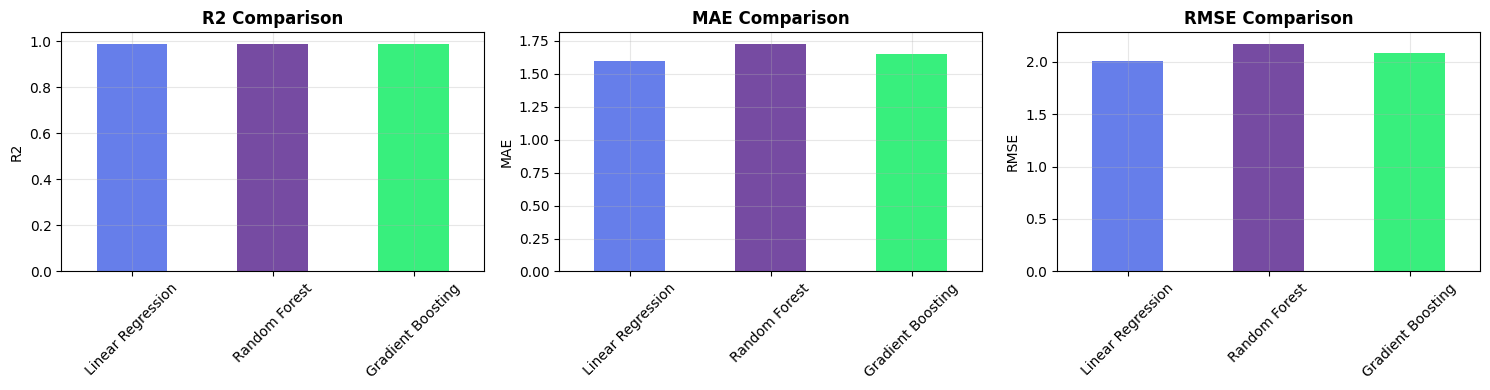

In [16]:
# Compare Models
results_df = pd.DataFrame(results).T
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(results_df.round(4))

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, metric in enumerate(['R2', 'MAE', 'RMSE']):
    results_df[metric].plot(kind='bar', ax=axes[idx], color=['#667eea', '#764ba2', '#38ef7d'])
    axes[idx].set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(metric)
    axes[idx].grid(alpha=0.3)
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [17]:
# Select best model (highest R2 score)
best_model_name = results_df['R2'].idxmax()
best_model = models[best_model_name]

print(f"\n🏆 Best Model: {best_model_name}")
print(f"R² Score: {results_df.loc[best_model_name, 'R2']:.4f}")


🏆 Best Model: Linear Regression
R² Score: 0.9890


In [18]:
# Feature Importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nFeature Importance:")
    print(feature_importance)
    
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='#667eea')
    plt.xlabel('Importance Score')
    plt.title('Feature Importance Analysis', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [19]:
# Save all models
model_package = {
    'best_model': best_model,
    'best_model_name': best_model_name,
    'all_models': models,
    'feature_names': list(X.columns),
    'results': results,
    'scaler': None  # Add if using StandardScaler
}

joblib.dump(model_package, 'enhanced_model.pkl')
print("\n✅ Enhanced model package saved as 'enhanced_model.pkl'")
print(f"Package contains: {best_model_name} + all trained models + metadata")


✅ Enhanced model package saved as 'enhanced_model.pkl'
Package contains: Linear Regression + all trained models + metadata


In [20]:
# Test prediction with new features
sample_input = pd.DataFrame({
    'Hours Studied': [8],
    'Previous Scores': [85],
    'Extracurricular Activities': [1],
    'Sleep Hours': [7],
    'Sample Question Papers Practiced': [5],
    'Study_Sleep_Ratio': [8/8],
    'Total_Effort': [8+5],
    'Previous_Score_Normalized': [0.85],
    'Sleep_Efficiency': [7*0.85]
})

prediction = best_model.predict(sample_input)[0]
print(f"\nSample Prediction: {prediction:.2f}")
print(f"Model used: {best_model_name}")


Sample Prediction: 80.23
Model used: Linear Regression
